# Gradient Stochastique et régularisation  $\ell^1$

**Compte rendu — Ugo Roccamatisi.**


<h1><a id='toc'></a>Sommaire</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li><a href="#I">I. Introduction </a></li>
        <ul>
        <li><a href="#I1">I.1. Un exemple en dimension 1</a></li>
        <li><a href="#I2">I.2. Un cas degeneré</a></li>
        <li><a href="#I3">I.3. Un exemple en plus grande dimension </a></li>
        </ul>
        <li><a href="#II">II. Optimisation numérique de $F_\lambda$ par ISTA</a></li>
        <ul>
            <li><a href="#II1">II.1. Réinterpretation de la méthode du gradient à pas constant</a></li> 
            <li><a href="#II2">II.2. ISTA </a></li> 
        </ul>
        <li><a href="#III">III. Application à l'optimisation stochastique</a></li>
    </ul>
</div>
<br>
<hr>

Importation des bibliothèques

In [4]:
# La bibliothèque pédagogique toynn_2023 n'était pas jointe : l'expérience
# finale utilise un petit réseau NumPy autonome, défini plus loin.
import numpy as np
from numpy import random as nprd
from matplotlib import pyplot as plt
import math as mt
from numpy import linalg as ln
nprd.seed(2025)

# I. Introduction <a id='I'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

On veut optimiser une fonction objectif régulière et convexe $F(w)$ mais on veut aussi privilégier les solutions parcimonieuses, c'est-à-dire les paramètres $w$ avec un grand nombre de composantes nulles. Pour cela, nous pénalisons la fonction objectif en ajoutant le terme ``régularisant'' $\lambda\|w\|_1$. Ici $\lambda\geq0$ est le paramètre de pénalisation et
$$
\|w\|_1 :=\sum_{j=0}^{N-1}|w_j|=|w_0|+|w_1|+\dots+|w_{N-1}|
$$
est la norme $\ell^1$ du vecteur $w$.

<a id='I1'></a>
<h2>I.1. Un exemple en dimension 1</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Considérons d'abord le cas $N=1$. Soit $\,\bar w\in\mathbb{R}\,$. On définit $\,f(w)=\frac12|w-\bar w|^2\,$ et pour $\,\lambda\ge 0\,$, on pose
$$\,f_\lambda(w):=f(w)+\lambda\|w\|_1\,=\, \frac12|w-\bar w|^2+\lambda|w|.$$
Le minimiseur de $\,f\,$ est évidemment $\,\bar w\,$. Dans quelle mesure est-il perturbé par le terme régularisant ? Découvrons-le en calculant le minimiseur de $\,f_\lambda$.

**Remarques préliminaires.** La fonction $f$ est strictement convexe (elle est 1-convexe) et $w\mapsto |w|$ est convexe donc la fonction résultante $f_\lambda$ est $1$-convexe. Nous concluons que $f_\lambda$ admet un unique minimiseur. On le note $w^*$ comme d'habitude.

Pour $\lambda>0$, la fonction $f_\lambda$ n'est pas dérivable en $0$. Cependant, elle  est dérivable en tout point $w\neq0$ et si $w^*\neq 0$, on a la condition d'optimalité

$$
0=f'_\lambda(w^*)=w^*-\bar w +\lambda \mathop{signe}(w^*). \tag{0}
$$
Inversement, si (0) est vrai en point $\hat w\neq0$, alors $\hat w =w^*$.

Pour l'analyse on considère quatre cas selon les valeurs de $\bar w$ et $\lambda$.

**1. Premier cas**$\,$ Si $\bar w=0$, on a évidemment $w^*=0$ $~~$($\,f_\lambda(0)=0\,$ et $\, f_\lambda(w)>0\,$ si $\,w\neq0\,$).

**2. Deuxième cas**$\,$ Si $\lambda=0\,$ alors $\,f_\lambda(w)=f(w)=\frac12|w-\bar w|^2\,$ et le minimiseur est $\,w^*=\bar w$.

**3. Troisième cas** $\,$Nous supposons $\,\lambda>0\,$ et $\,\bar w>0\,$. Nous remarquons d'abord que $\,w^*\geq 0$.
En effet, pour $\,w<0\,$, on a  $\quad|w-\bar w|= \bar w - w>\bar w = |0-\bar w|,\quad $ donc
$\quad
f_\lambda(w)>f_\lambda(0)\geq f_\lambda(w^*)
\quad$ et nous voyons que $\,w^*\neq w$.

Ensuite, si $\,w^*>0\,$, alors par (0) nous avons $\,w^*=\bar w-\lambda$. Ce nombre est positif si et seulement si $\,\bar w>\lambda$. Nous concluons que :

$$
w^*=\begin{cases}\bar w-\lambda &\text{if } \bar w>\lambda,\\
\quad 0 & \text{if } 0<\bar w\leq\lambda. \end{cases}
$$

**4. Quatrième cas** Nous supposons toujours $\,\lambda>0\,$ mais $\,\bar w<0$. En raisonnant comme ci-dessus, on voit que $\,w^*\leq 0\,$ puis

$$
w^*=\begin{cases}\bar w+\lambda &\text{if } \bar w<-\lambda,\\
\quad 0 & \text{if } -\lambda\leq \bar w<0. \end{cases}
$$

**Conclusion** $\,$En résumé :
$$
w^*=\begin{cases}\bar w-\lambda\ \text{sign}\,\bar w &\text{if } |\bar w|>\lambda,\\
\qquad 0 & \text{if } |\bar w|\leq \lambda. \end{cases}
$$

On peut mesurer la distance entre le minimiseur de $\,f\,$ et le minimiseur de $\,f_\lambda\,$ :

$$
|\bar w|>\lambda\ \Longrightarrow\ |w^* -\bar w|=\lambda\qquad\text{et}\qquad
|\bar w|\le\lambda\ \Longrightarrow\ |w^* -\bar w|=|\bar w|.
$$

Dans tous les cas :$\qquad\qquad\qquad\qquad\qquad|w^* -\bar w|\leq \lambda$.

Voici les tracés du graphique de la fonction $\bar w\mapsto w^*$ pour $\lambda =0$, $\lambda=1$, $\lambda=2$ et $\lambda=4$.

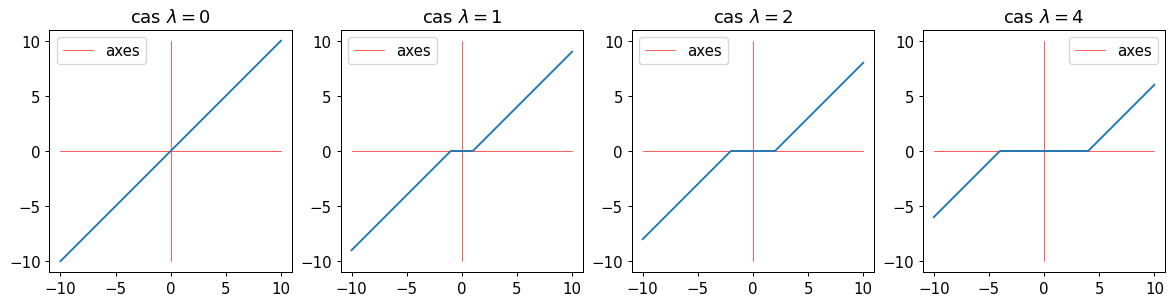

In [19]:
plt.rcParams.update({'font.size': 12})
if 1==1:
    buildf_lbda = lambda L: lambda w: np.where(w>L, w-L, 
                                               np.where( w<-L, w+L, 0))
    lbda = (0 , 1, 2 , 4)
    w=np.linspace(-10,10,41)
    plt.figure(figsize=(16,3.5))
    for i in range(4):
        plt.subplot(141 + i)
        plt.plot([-10, 10], [0, 0],'r',linewidth=.5, label='axes')
        plt.plot([0, 0], [-10, 10],'r',linewidth=.5)
        plt.plot(w, buildf_lbda(lbda[i])(w))
        plt.title(r"cas $\lambda=$" + str(lbda[i]))
        plt.legend()

<a id='I2'></a>
<h2>I.2. Un cas dégénéré</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

On considère ici, $N=2$ et 
$$
F(w):=\dfrac12(2w_0 + w_1 - 1)^2.
$$

**Exercice 1**

a) La fonction $F$ est-elle convexe ? fortement convexe ? coercive?

b) Trouvez les minimiseurs dans $\mathbb{R}^2$ de $F$.

c) Soit $\lambda>0$. Trouvez les minimiseurs de

$$
F_\lambda(w)=F(w)+\lambda\|w\|_1:= \dfrac12(2w_0 + w_1 - 1)^2 +\lambda (|w_0| +|w_1|).
$$

*__Indication :__ justifier que si la compososante $w^*_j$ d'un point de minimum $w^*$ est non nulle alors $\dfrac {\partial F_\lambda(w^*)}{\partial w_j}$ est bien défini et nul.*

d) Interprétez le résultat de (c) : quels sont les effets du terme régularisant $\lambda \|w\|_1$ ?

**Solution 1.a.** $F(w)=\frac12(2w_0+w_1-1)^2$ est convexe : sa Hessienne est $\begin{pmatrix}4&2\\2&1\end{pmatrix}$, positive mais de rang 1. Elle n'est ni fortement convexe ni coercive : le long de $(w_0,w_1)=(t,1-2t)$, elle vaut toujours zéro alors que la norme tend vers l'infini.

**Solution 1.b.** Tous les points de la droite $2w_0+w_1=1$ minimisent $F$, avec valeur minimale $0$.

**Solution 1.c.** Pour une valeur fixée $t=2w_0+w_1$, on a $|w_0|+|w_1|\ge |t|/2$, avec égalité uniquement pour $w_0=t/2,w_1=0$. Il reste à minimiser $\frac12(t-1)^2+\frac\lambda2|t|$, dont la solution est $t^*=\max(1-\lambda/2,0)$. Pour $0<\lambda<2$, l'unique minimiseur est $(1/2-\lambda/4,0)$ ; pour $\lambda\ge2$, c'est $(0,0)$.

**Solution 1.d.** La pénalité sélectionne un minimiseur parcimonieux sur une direction plate du problème initial ; dès que $\lambda>0$, la composante $w_1$ est exactement nulle. Pour $\lambda\ge2$, tout le vecteur devient nul.

<a id='I3'></a>
<h2>I.3. Un exemple en plus grande dimension</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Considérons maintenant une fonction quadratique non dégénérée comme en **I.1** mais en dimension supérieure $N\geq 1$. Nous fixons $\bar w\in \mathbb{R}^N$ et une suite de nombres $a_0,a_1,\dots,a_{N-1}>0$ et nous posons pour $w\in\mathbb{ R}^N$,

$$\tag{1}
F(w):=\dfrac12\sum_{j=0}^{N-1} a_j (w_j-\bar w_j)^2\qquad\qquad\qquad\qquad\qquad\qquad\qquad\qquad
\qquad\qquad=\dfrac{a_0}2(w_0-\bar w_0)^2 + \dfrac{a_1}2(w_1-\bar w_1)^2+\dots + \dfrac{a_{N-1}} 2(w_{N-1}-\bar w_{N-1})^2.
$$

Comme dans la partie <a href="#I1">I.1.</a> la fonction $\,F\,$ est fortement convexe : elle est $\gamma$-convexe pour
$$\gamma=\min\{a_j,j=0,\dots,N-1\}\, >0.$$
On note $\,\bar w\,$ l'unique minimiseur de $\,F$.

Fixons $\lambda>0$ et fixons comme plus haut, $F_\lambda(w):=F(w)+\lambda \|w\|_1$. La fonction $F_\lambda$ est à nouveau fortement convexe, on note son unique minimiseur $w^*$. 

À quelle distance de $w^*$ se trouve $\bar w$ ? À quel point est-il plus parcimonieux que $\bar w$ ? Pour le savoir nous allons déterminer explicitement $w^*$.

Remarquons tout d'abord que $F_\lambda$ se divise en $N$ fonctions d'un seul paramètre :

$$
F_\lambda(w)=\sum_{j=0}^{N-1} F^{(j)}_\lambda (w_j)\qquad
\text{with}\quad F^{(j)}_\lambda (w_j)=\dfrac{a_j}2(w_j-\bar w_j)^2 + \lambda |w_j|
= a_j\left\{\dfrac12(w_j-\bar w_j)^2 + \dfrac{\lambda}{a_j} |w_j|\right\}.
$$

Puisque les paramètres des fonctions $F_\lambda^{(j)}$ sont indépendants les uns des autres, nous pouvons optimiser séparément les $F_\lambda^{(j)}$. L'expression entre accolades est de la forme $f_{\lambda/a_j}(w_j)$ étudiée en <a href="#I1">I.1.</a>. Nous en déduisons que

$$\tag{2}
\text{Pour }j=0,\dots,N-1,\ \quad w^*_j=\begin{cases}\bar w_j-\dfrac\lambda{a_j}\ \text{signe}\, \bar w_j &\text{si } |a_j\bar w_j|>\lambda,\\
\qquad 0 &\text{si } |a_j\bar w_j|\leq \lambda. \end{cases}
$$

Notez que $|a_j\bar w_j|= \left| \dfrac{\partial F}{\partial w_j}(0)\right|$ mesure la sensibilité de $F$ par rapport aux variations de la $j$-ième variable .

Nous pouvons interpréter la formule ci-dessus comme suit :

$\quad\ $a) si cette sensibilité est suffisamment petite, _c'est-à-dire_ $\ \left| \dfrac{\partial F}{\partial w_j}(0)\right|\leq \lambda\ $ alors $w^*_j$ vaut 0. On a alors
$$
\tag{3a}
|a_j(w^*_j - \bar w_j)| \leq\lambda.
$$


$\quad\ $b) pour des sensibilités plus grandes $\ \left| \dfrac{\partial F}{\partial w_j}(0)\right| > \lambda\ $, $w^*_j$ est une approximation de $\bar w_j$, avec
$$
\tag{3b}
|a_j(w^*_j - \bar w_j)| =\lambda.
$$

**Remarque.** Les conditions d'optimalité de la pénalité $\ell^1$ donnent, pour chaque $j$,
$$
\left|\frac{\partial F(w^*)}{\partial w_j}\right|\leq\lambda.
$$
Si toutes les autres coordonnées sont fixées à leur valeur dans $w^*$, définissons
$$
S_j=\left\{t\in\mathbb R:\left|\frac{\partial F}{\partial w_j}
(w_0^*,\ldots,w_{j-1}^*,t,w_{j+1}^*,\ldots,w_{N-1}^*)\right|\leq\lambda\right\}.
$$
Alors $w_j^*$ est un point de $S_j$ qui minimise $|t|$ : le seuillage privilégie la coordonnée nulle dès qu'elle satisfait la borne sur le gradient. Cette caractérisation vaut également pour une fonction $F$ convexe et dérivable.


Nous voyons que si nous choisissons $\lambda$ petit, $w^*$ sera une petite perturbation du minimiseur exact de $F$. De plus, si mettre $w^*_j$ à 0 ne crée qu'un gradient négligeable (inférieur à $\lambda$) alors $w^*_j$ vaut 0. En ce sens, la régularisation favorise la *parcimonie* de $w^*$.

# II. Optimisation numérique de $F_\lambda$ par ISTA<a id='II'></a> 

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

__(__ ***''ISTA'' signifie ``Iterative Shrinkage-Thresholding Algorithm''*** __)__

Nous voulons optimiser une fonction convexe régulière $F:\mathbb{R}^N\to \mathbb{R}$ avec un terme de régularisation $\lambda \|w\|_1$ où le paramètre $\lambda\geq 0$ est donné.

<a id='II1'></a>
<h2>II.1. Réinterpretation de la méthode du gradient à pas fixe</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Supposons d'abord $\,\lambda =0$. Dans ce cas $\,F_\lambda=F\,$ est régulière et nous pouvons utiliser la méthode de gradient avec pas fixe $\,\alpha>0$. Nous commençons par réinterpréter cette méthode comme une succession de résolutions de problèmes d'optimisation. Nous commençons par un vecteur initial $\,w^0\in\mathbb{R}^N\,$ et nous construisons récusivement la suite $w^0$, $w^1$,$w^2$, $\ points$, avec les règles suivantes :

$\qquad$a) A l'étape $\,k$, connaissant l'itération courante $\,w^k$, on définit la fonction

$$\tag{5}
\Phi^k(w):=F(w^k) +\left<\nabla F(w^k);w-w^k\right> + \dfrac1{2\alpha}\|w-w^k\|^ 2
$$

Pour construire la fonction $\,\Phi^k\,$ nous sommes parti du développement de Taylor au premier ordre de $F$ et nous avons ajouté le terme quadratique $\,\|w-w^k\|^2/(2\alpha)$.  $\Phi^k$ est donc une approximation (au premier ordre) de $\,F\,$ près de $\,w^k\,$ et est une fonction quadratique définie positive.
En particulier, il admet un minimiseur unique.

$\qquad$b) $w^{k+1}\,$ est défini comme le minimiseur de $\,\Phi^k$.

Il est facile de déterminer le minimiseur de la fonction quadratique $\Phi^k$. Nous trouvons

$$
\tag{6}
w^{k+1} = w^k - \alpha \nabla F(w^k)
$$

Comme annoncé, nous retrouvons la formule donnant $\,w^{k+1}\,$ en fonction de $w^k$ pour la méthode de descente de gradient de pas $\alpha$.

**Exercice 2** Justifier la formule (6).

**Solution 2.** Le gradient du modèle $\Phi^k$ en $w$ est $\nabla F(w^k)+(w-w^k)/\alpha$. L'annuler donne $w^{k+1}=w^k-\alpha\nabla F(w^k)$, formule (6).

<a id='II2'></a>
<h2>II.2. ISTA</h2>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

Nous supposons maintenant $\lambda>0$ de sorte qu'on a un terme de régularisation $\ell^1$. Pour optimiser $F_\lambda$, nous partons toujours d'une estimation initiale $w^0$ et construisons récursivement une suite $w^0$, $w^1$, $w^2$, $\dots$ où à l'étape $k,\,$ $w^{k+1}$ est défini comme le minimiseur de

$$\tag{7}
\Phi_\lambda^k(w):= \Phi^k(w)+\lambda \|w\|_1.
$$

Notez que nous **ne remplaçons pas** le terme de pénalisation par son développement de Taylor au voisinage de $w^k$.

En rappelant la définition de $\ \Phi^k,\ $ nous avons
$$\tag{8}
\Phi_\lambda^k(w)=F(w^k) +\left<\nabla F(w^k);w-w^k\right> + \dfrac1{2\alpha}\|w-w^k\| ^2 +\lambda\|w\|_1.
$$

Pouvons-nous trouver une formule explicite pour $w^{k+1}$ ? Oui! En fait, nous sommes dans la situation de **I.2.** Notons $\,\bar w^k\,$ le minimiseur de $\,\Phi^k$. Par (6) nous avons

$$\tag{9}\bar w^k=w^k-\alpha\nabla F(w^k)$$

et la fonction $\Phi^k$ se réécrit comme
$$\tag{10}
\Phi^k(w) = c_k + \dfrac1{2\alpha} \|w - \bar w^k\|_2^2.
$$

**Exercice 3** Justifier la formule (10).

**Solution 3.** Développer $\|w-(w^k-\alpha\nabla F(w^k))\|^2/(2\alpha)$ : on retrouve le terme linéaire $\langle\nabla F(w^k),w-w^k\rangle$ et le terme quadratique $\|w-w^k\|^2/(2\alpha)$ ; les autres termes ne dépendent pas de $w$ et sont regroupés dans $c_k$.

En tenant compte de (7) et (10) on voit que $w^{k+1}$ est le minimiseur de
$$
G(w):=\dfrac1{2\alpha} \|w - \bar w_k\|_2^2 + \lambda \|w\|_1.
$$
Cette fonction est de la forme (1) dans la partie **I.2.** avec $a_0=a_1=\dots=a_{N-1}=1/\alpha$. Ainsi, en utilisant la formule (2), nous avons

$$\tag{11}
\text{pour }j=0,\dots,N-1,\ \ w^{k+1}_j=
\begin{cases} \bar{w}^k_j - \lambda\alpha\ \text{sign}\, \bar w^k_j &
\text{si } |\bar{w}^k_j| > \lambda\alpha ,\\
\qquad 0 &
\text{si } |\bar{w}^k_j| \leq \lambda\alpha. \end{cases}\qquad
$$

**Résumé.** Nous déduisons de (9) et (11) une formule explicite pour $w^{k+1}$. Après l'initialisation, ISTA s'exécute comme suit : pour $k=0,1,\dots$ calculer
$$\tag{12}
\begin{array}{rl} \hfill\bar{w}^k :=&w^k-\alpha\nabla F(w^k), \\ \\
\text{pour }j=0,\dots,N-1,\quad \ w^{k+1}_j:=&
\begin{cases} \bar{w}^k_j - \lambda\alpha\ \text{sign}\, \bar w^k_j &
\text{si } |\bar{w}^k_j| > \lambda\alpha ,\\
\qquad 0 &
\text{si } |\bar{w}^k_j| \leq \lambda\alpha. \end{cases}
\end{array}
$$

**Exercice 4** Nous souhaitons tester cet algorithme avec
$$
F(w):=\sum_{j=0}^{N-1} \sin^2(\pi (w_j - w^*_j)),
$$
où la suite $w^*_0,\dots,w^*_{N-1}$ est donnée.<br>
Justifiez la formule pour $\nabla F$ donnée ci-dessous dans la définition de la fonction python  _builGradF_.


**Solution 4.** Pour $F(w)=\sum_j\sin^2(\pi(w_j-w_j^*))$, les coordonnées sont indépendantes. La règle de chaîne donne $\partial_j F=2\pi\sin(\pi(w_j-w_j^*))\cos(\pi(w_j-w_j^*))=\pi\sin(2\pi(w_j-w_j^*))$.

In [58]:
## Exemple d'une fonction régulière non convexe

# Constructeur de F et Grad F
buildF = lambda barw : lambda w : np.sum(
                            np.sin(np.pi*(w - barw))**2 )
buildGradF = lambda barw : lambda w : np.pi*np.sin(2*np.pi*(w - barw))

# Fonction pour compter le nombre de composantes non nulles d'un vecteur
count_non_zeros= lambda w: np.sum(np.where(w==0, 0, 1)) 

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

**Exercice 5** Mettez en oeuvre ISTA (compléter la quatrième boîte ci-dessous) pour la fonction précédente. On prendra $N=100$ et $\lambda=2$. 

Faites des représentations graphiques des valeurs prises par $F_\lambda$ au cours des itérations, ainsi que du nombre de composantes non nulles de chaque itéré.<br>

Faites varier la valeur de $\lambda$ et noter vos observations et commentaires dans la boîte dédiée.

_Indication :_ La méthode numpy _np.where_ peut se révéler utile. Si _w_ est un tableau numpy, disons un vecteur, la  commande
<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
v$=$np.where(abs(w)<1, f(w), g(w))<br>
construit un tableau numpy _v_ de même taille que _w_ avec la règle suivante.   
$$
\text{v}[i]=\begin{cases} \text{f}(\text{w}[i])&\text{si }\text{abs}(\text{w}[i])<1,\\
\text{g}(\text{w}[i])&\text{sinon}.\end{cases}
$$

Nous indiquons aussi que la norme $\ell^1$ d'un tableau numpy _w_ s'obtient à la l'aide de la méthode _numpy.linalg.norm_. Par exemple, la commande<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
norme_l1$=$ln.norm(w, ord=1))<br>
calcule la somme  $\sum_i$*w*[$i$] (et attribue cette valeur à la variable *norme_l1*).


In [61]:
## (Préliminaire pour l'exercice 5)
# Construction du problème
N = 100
w_star = .5*nprd.random(N) - .25
F, GradF = buildF(w_star), buildGradF(w_star)

In [62]:
## Pas inférieur à 1/L : ici L<=2π² pour le gradient de F.
alpha=.04
Lambda=2
threshold=alpha*Lambda
Nitermax=80

In [63]:
## (Préliminaire pour l'exercice 5)
# Initialisation
w = .5*nprd.random(N) - .25
niter=0

# On créé deux listes pour l'analyse du comportement de l'algorithme d'optimisation.
# La liste E pour stocker les valeurs de la fonctions à minimiser.
E = [(F(w) + Lambda*ln.norm(w, ord=1))]
# La liste NZ pour stocker le nombre d'éléments nons nuks des w^k.
NZ = [count_non_zeros(w)] 

In [64]:
# Étape de gradient suivie du seuillage doux coordonnée par coordonnée.
while niter<Nitermax:
    z=w-alpha*GradF(w)
    w=np.sign(z)*np.maximum(np.abs(z)-threshold,0)
    E.append(F(w)+Lambda*ln.norm(w,ord=1))
    NZ.append(count_non_zeros(w))
    niter+=1
print('Fλ initial/final :',round(E[0],4),round(E[-1],4),'; coefficients non nuls :',NZ[0],NZ[-1])

Fλ initial/final : 58.748 17.9899 ; coefficients non nuls : 100 62


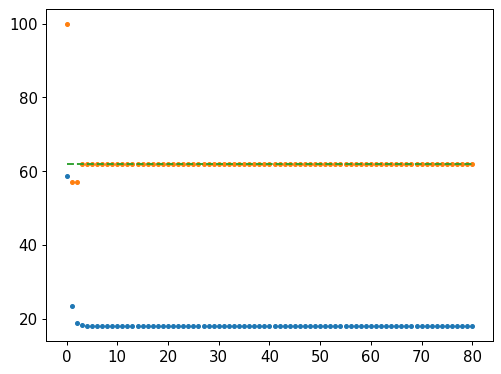

In [65]:
# Solution 5 (suite) Représentations graphiques.
E = np.array(E)
minE = np.min(E)
plt.plot(E,".")
plt.show()


plt.plot(NZ,".")
plt.plot([0, Nitermax],[NZ[-1],NZ[-1]],"--")
plt.show()



In [66]:
# Comparaison sur le même départ, sans réutiliser les itérés précédents.
initial=np.random.default_rng(7).uniform(-.25,.25,size=N)
for lam in (.5,2.,5.):
    trial=initial.copy()
    for _ in range(80):
        z=trial-alpha*GradF(trial)
        trial=np.sign(z)*np.maximum(np.abs(z)-alpha*lam,0)
    print(f'λ={lam}: F={F(trial):.3f}, Fλ={F(trial)+lam*np.abs(trial).sum():.3f}, non-nuls={np.count_nonzero(trial)}')

λ=0.5: F=0.588, Fλ=6.193, non-nuls=90
λ=2.0: F=8.680, Fλ=17.990, non-nuls=62
λ=5.0: F=20.698, Fλ=20.698, non-nuls=0


**Solution 5 — résultats.** Sur ce départ, λ=0,5 conserve 90 coefficients non nuls ; λ=2 en conserve 62 ; λ=5 produit le vecteur nul. La valeur de F seule augmente avec la contrainte de parcimonie : la pénalité change l’objectif optimisé.


**Exercice 6** Nous proposons la fonction

$$
F(w):=\sum_{j=0}^{N-1} \sin^2(w_j - w_{j-1}),
$$
où les indices $j$ sont compris modulo $N$.

a) Justifiez la formule de $\nabla F$ donnée dans la boîte suivante.

b) Quels sont les minimiseurs de $F$ ?

c) Quels sont les minimiseurs de $F_\lambda$ pour $\lambda>0$ ?

d) Appliquez votre implémentation d'ISTA à l'optimisation de $F_\lambda$. Dans le cas $\lambda=0$, est-ce que les itérations convergent vers un minimiseur de $F$ ?

e) Dans le cas $\lambda>0$, est-ce que les itérations convergent vers un minimiseur de $F_\lambda$ ? Sinon, pourquoi ?

f) Les itérées convergent-elles vers un vecteur proche d'un minimiseur de $F$ ? Les solutions trouvées sont elles parcimonieuses ? Vos résultats numériques sont-ils cohérents avec (4) ? Justifier.

In [69]:
F = lambda w : np.sum( np.sin(w - np.roll(w,1))**2 )
GradF = lambda w : 2*np.sin(2*w - np.roll(w,1) - np.roll(w,-1))*np.cos(np.roll(w,1)                                                                   - np.roll(w,-1))

**Solution 6.** La dérivée du terme $\sin^2(w_j-w_{j-1})$ par rapport à $w_j$ vaut $\sin(2(w_j-w_{j-1}))$ ; celle du terme suivant est $-\sin(2(w_{j+1}-w_j))$. Leur différence se réécrit sous la forme donnée avec l'identité trigonométrique des sinus. Les minimiseurs globaux de $F$ satisfont $w_j-w_{j-1}\in\pi\mathbb Z$ pour tout j (sur le cycle) ; il y en a une infinité. Pour λ>0, $F_λ\ge0$ et le vecteur nul est son **unique** minimiseur global. F est non convexe : ISTA à pas admissible peut converger vers un point stationnaire non global, donc aucune garantie de convergence vers zéro depuis un départ arbitraire. Un itéré stationnaire vérifie $|\partial_jF(w)|\le\lambda$, avec égalité de module si $w_j\ne0$. Le seuillage favorise des zéros exacts, mais la proximité avec un minimiseur de F dépend du départ et de λ.

**Résultats numériques.** Ici, λ=0 approche un minimiseur de F (F≈2,7×10⁻⁴) mais garde 100 coefficients non nuls ; les trois valeurs λ>0 testées convergent vers le vecteur nul, qui minimise Fλ. Ce constat pour ce départ ne prouve pas la convergence globale pour tout départ.


λ=0: Fλ=0.00027, F=0.00027, non-nuls=100, max|∂F|=0.0011
λ=0.05: Fλ=0.00000, F=0.00000, non-nuls=0, max|∂F|=0.0000
λ=0.2: Fλ=0.00000, F=0.00000, non-nuls=0, max|∂F|=0.0000
λ=1.0: Fλ=0.00000, F=0.00000, non-nuls=0, max|∂F|=0.0000


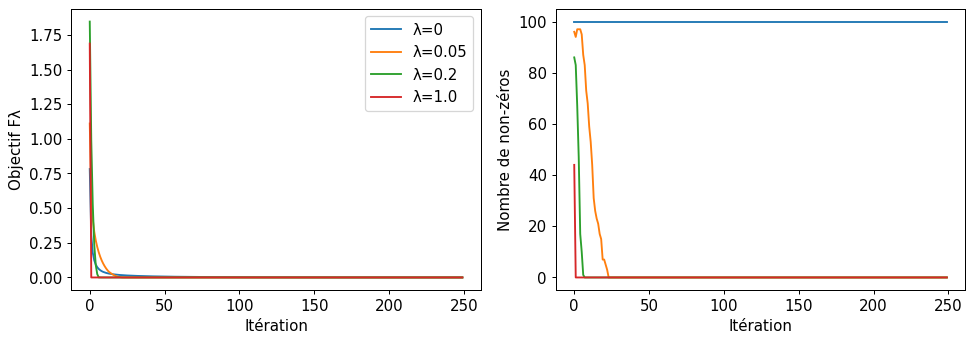

In [71]:
# Expérience de l'exercice 6 : départ identique pour tous les λ.
F_ring=F;Grad_ring=GradF
r0=np.random.default_rng(123).uniform(-.25,.25,size=100)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for lam in (0,.05,.2,1.):
    v=r0.copy();values=[];counts=[]
    for _ in range(250):
        z=v-.10*Grad_ring(v)
        v=np.sign(z)*np.maximum(np.abs(z)-.10*lam,0)
        values.append(F_ring(v)+lam*np.abs(v).sum());counts.append(np.count_nonzero(v))
    axes[0].plot(values,label=f'λ={lam}');axes[1].plot(counts,label=f'λ={lam}')
    print(f'λ={lam}: Fλ={values[-1]:.5f}, F={F_ring(v):.5f}, non-nuls={counts[-1]}, max|∂F|={np.max(np.abs(Grad_ring(v))):.4f}')
axes[0].set(xlabel='Itération',ylabel='Objectif Fλ');axes[1].set(xlabel='Itération',ylabel='Nombre de non-zéros')
axes[0].legend();fig.tight_layout();plt.show()

# III. Application à l'optimisation stochastique <a id='III'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

__Exercice 7.__


a) Implémentez ISTA dans le cadre du problème de classification et de réseaux de neurones jouets définis ci-dessous. On prendra le taux d'apprentissage $\alpha=5\cdot10^{-2}$ et $\lambda=10^{-3}$.

Pour ce qui est de l'algorithme, les changements par rapport à ISTA sont :

$\qquad\alpha$) dans la première étape de (12) on remplace $\nabla F(A)$ par une moyenne des $\nabla f_i(A)$ avec $i$ parcourant un mini-lot $I$ d'indices tirés au hasard.

$\qquad\beta$) On utilise une stratégie de taux d'apprentissage décroissants.

Pour l'éude (graphique) de l'algorithme, on stockera l'erreur totale sur l'échantillon d'apprentissage ainsi que le nombre de composantes non nulles du paramètre $A$ au cours des époques.

*Indications :*<br> 
$\qquad\qquad\bullet$ La méthode _nn.count_non_zero(A)_ renvoie le nombre de composantes non nulles de la liste de coefficients _A_.<br> 
$\qquad\qquad\bullet$ Combinée avec *np.where()*, la méthode *nn.maps()* est très pratique pour calculer les itérés de ISTA.<br>Si $f$ est une fonction qui prend en paramètres un tableau numpy _X_ et (éventuellement) un paramètre _p_ et renvoie un tableau de la même taille que _X_ alors, la méthode _nn.maps(f,A,param=p, output=False)_ remplace tous les coefficients $A_i$ de _A_ par *f(*$A_i$*,p)*.<br>




b) Observez les résultats numériques obtenus avec les paramètres proposés dans les deux boîtes suivantes. 

c) Essayez différentes valeurs pour $\lambda$ et commentez.

**Solution 7.** La partie réseau est réalisée ci-dessous avec un réseau NumPy (2–8–8–8–1) et une classification en anneau équivalente : `toynn_2023` n'était pas inclus. Le gradient de la perte est moyenné sur chaque mini-lot, suivi d'un seuil doux sur les poids ; les biais ne sont pas pénalisés. Un taux décroissant permet d'amortir les oscillations. Les chiffres et frontières de décision sont ceux de cette réalisation autonome, et non de la bibliothèque pédagogique non fournie.

**Résultats numériques.** Après 400 époques, la précision test vaut environ 0,825 sans pénalité, 0,805 pour λ=0,001 (141 poids non nuls sur 152), et 0,703 pour λ=0,01 (tous les poids pénalisés s’annulent). Une pénalité trop forte détruit ici la capacité de classification.


Classes train : [662 338]


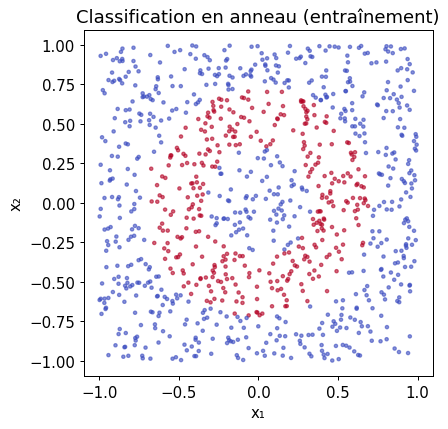

In [76]:
# Jeu « anneau » reproductible, deux classes : centre + extérieur vs bande annulaire.
from scipy.special import expit
rng_ring=np.random.default_rng(2025)
X_ring=rng_ring.uniform(-1,1,size=(1400,2))
radius=np.linalg.norm(X_ring,axis=1)
y_ring=((radius>.35)&(radius<.72)).astype(float)
X_tr,X_te=X_ring[:1000],X_ring[1000:]
y_tr,y_te=y_ring[:1000],y_ring[1000:]
fig,ax=plt.subplots(figsize=(5,5));ax.scatter(*X_tr.T,c=y_tr,cmap='coolwarm',s=7,alpha=.6)
ax.set(xlabel='x₁',ylabel='x₂',title='Classification en anneau (entraînement)');plt.show()
print('Classes train :',np.bincount(y_tr.astype(int)))

In [77]:
# Réseau entièrement connecté : trois couches cachées tanh, sortie sigmoïde.
shape=(2,8,8,8,1);n_epochs=400;batch_size=64
initial_rng=np.random.default_rng(41)
initial_W=[initial_rng.normal(scale=np.sqrt(2/(a+b)),size=(a,b)) for a,b in zip(shape[:-1],shape[1:])]
initial_b=[np.zeros((1,b)) for b in shape[1:]]

def forward(X,weights,biases):
    activations=[X]
    for W,b in zip(weights[:-1],biases[:-1]):activations.append(np.tanh(activations[-1]@W+b))
    activations.append(expit(activations[-1]@weights[-1]+biases[-1]))
    return activations

def loss_and_grads(X,y,weights,biases):
    act=forward(X,weights,biases);p=act[-1].ravel();target=y.ravel()
    pclip=np.clip(p,1e-12,1-1e-12)
    loss=-np.mean(target*np.log(pclip)+(1-target)*np.log1p(-pclip))
    delta=((p-target)/len(X))[:,None];dW=[None]*len(weights);db=[None]*len(weights)
    for j in range(len(weights)-1,-1,-1):
        dW[j]=act[j].T@delta;db[j]=delta.sum(axis=0,keepdims=True)
        if j:delta=(delta@weights[j].T)*(1-act[j]**2)
    return loss,dW,db

In [78]:
def train_stochastic_ista(lam,seed=60):
    W=[w.copy() for w in initial_W];b=[v.copy() for v in initial_b]
    local_rng=np.random.default_rng(seed);losses=[];counts=[];acc=[]
    for epoch in range(n_epochs):
        lr=.05/np.sqrt(1+epoch/30)  # pas décroissant par époque.
        for idx in np.array_split(local_rng.permutation(len(X_tr)),int(np.ceil(len(X_tr)/batch_size))):
            _,dW,db=loss_and_grads(X_tr[idx],y_tr[idx],W,b)
            # Pas de gradient stochastique puis opérateur proximal L1 sur les poids.
            W=[np.sign(z)*np.maximum(np.abs(z)-lr*lam,0) for z in (w-lr*dw for w,dw in zip(W,dW))]
            b=[bb-lr*dbb for bb,dbb in zip(b,db)]
        objective,_,_=loss_and_grads(X_tr,y_tr,W,b)
        losses.append(objective);counts.append(sum(np.count_nonzero(w) for w in W))
        acc.append(np.mean((forward(X_te,W,b)[-1].ravel()>=.5)==y_te))
    return W,b,np.asarray(losses),np.asarray(counts),np.asarray(acc)
print('Poids du réseau :',sum(w.size for w in initial_W),'(biais non pénalisés)')

Poids du réseau : 152 (biais non pénalisés)


In [79]:
# Réglage demandé : α initial=0,05 et λ=10⁻³ ; autres valeurs pour comparer.
experiments={lam:train_stochastic_ista(lam) for lam in (0,.001,.01)}
for lam,(_,_,losses,counts,acc) in experiments.items():
    print(f'λ={lam}: perte train={losses[-1]:.4f}, accuracy test={acc[-1]:.3f}, poids non nuls={counts[-1]}/{counts[0]}')

λ=0: perte train=0.3475, accuracy test=0.825, poids non nuls=152/152
λ=0.001: perte train=0.3880, accuracy test=0.805, poids non nuls=141/152
λ=0.01: perte train=0.6397, accuracy test=0.703, poids non nuls=0/149


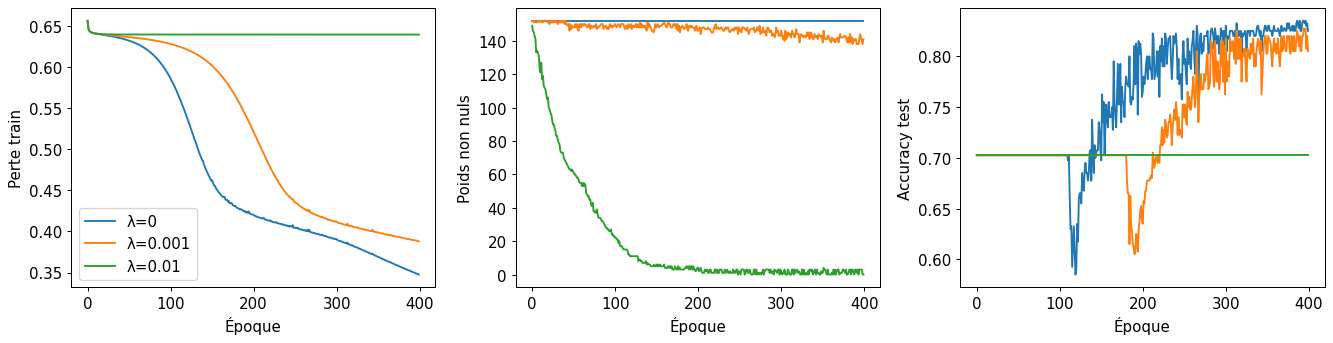

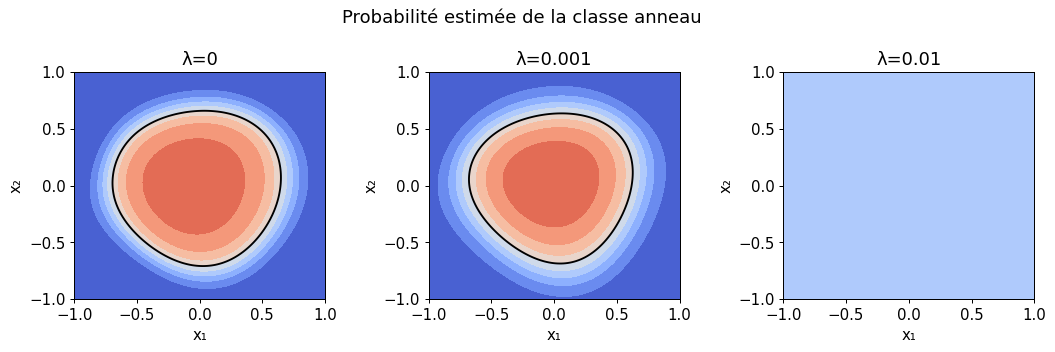

In [80]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for lam,(_,_,losses,counts,acc) in experiments.items():
    axes[0].plot(losses,label=f'λ={lam}');axes[1].plot(counts,label=f'λ={lam}');axes[2].plot(acc,label=f'λ={lam}')
axes[0].set(xlabel='Époque',ylabel='Perte train');axes[1].set(xlabel='Époque',ylabel='Poids non nuls')
axes[2].set(xlabel='Époque',ylabel='Accuracy test');axes[0].legend();fig.tight_layout();plt.show()
fig,axes=plt.subplots(1,3,figsize=(12,4))
xx,yy=np.meshgrid(np.linspace(-1,1,120),np.linspace(-1,1,120));grid=np.c_[xx.ravel(),yy.ravel()]
for ax,(lam,(W,b,_,_,_)) in zip(axes,experiments.items()):
    prob=forward(grid,W,b)[-1].reshape(xx.shape)
    ax.contourf(xx,yy,prob,levels=np.linspace(0,1,11),cmap='coolwarm',vmin=0,vmax=1)
    ax.contour(xx,yy,prob,levels=[.5],colors='k')
    ax.set(title=f'λ={lam}',xlabel='x₁',ylabel='x₂')
fig.suptitle('Probabilité estimée de la classe anneau');fig.tight_layout();plt.show()

<a id='bot'></a>
<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I3">I.3</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II1">II.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II2">II.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>